# **Amazon Prime Video - Exploratory Data Analysis**

##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual
##### **Team Member 1 -** *Aman Kumar*

# **Project Summary -**

Amazon Prime Video is one of the largest video-streaming platforms in the world, and like every major streaming service it competes for subscriber attention by continuously growing and refreshing its content catalogue. This project performs an end-to-end Exploratory Data Analysis (EDA) on a dataset of **9,871 unique titles** (movies and TV shows) available on Amazon Prime Video in the United States, together with a companion dataset of **124,235 cast and crew credits** for those titles.

The `titles.csv` file carries the core metadata for every title - its name, type (MOVIE/SHOW), description, release year, age certification, runtime, genres, production countries, number of seasons (for shows), IMDb id/score/votes and TMDb popularity/score. The `credits.csv` file lists every actor and director associated with a title, along with the character they played (for actors).

The goal of the analysis is to convert this raw catalogue data into business-usable insight. Concretely, the notebook works through: (1) loading and cleaning both files - handling missing values in `age_certification`, `seasons`, `imdb_score/votes`, `tmdb_score/popularity` and `description`, de-duplicating rows, and parsing the stringified list columns (`genres`, `production_countries`) into real Python lists; (2) understanding each variable individually (univariate analysis) - the Movie vs. TV Show split, the growth of the catalogue over time, the spread of genres, production countries, age certifications, and runtimes; (3) bivariate and multivariate analysis - how IMDb and TMDb scores relate to each other and to popularity/votes, how average ratings differ by genre and by release decade, and which actors and directors appear most often on the platform; and (4) synthesising all of this into a small set of concrete, actionable recommendations for content strategists, marketing teams and investors.

Across 16 visualisations (bar charts, line charts, histograms, box plots, scatter plots, a correlation heatmap and a pair plot) the analysis finds that Amazon Prime's catalogue is overwhelmingly movie-heavy, that the library has grown explosively since 2015 (driven almost entirely by licensed/older movie back-catalogue plus a fast-growing slice of original content), that Drama, Comedy and Documentary are the dominant genres, that the US dominates production but a meaningful "long tail" of international content exists, and that IMDb and TMDb scores are strongly correlated but diverge often enough that neither should be used alone to judge quality. The notebook closes with a business-objective section translating these findings into recommendations around content acquisition, marketing focus and investment priorities, followed by a concise conclusion.

# **GitHub Link -**

https://github.com/rajputaman123/Amazon-Prime-EDA

# **Problem Statement**

In today's competitive streaming industry, platforms like Amazon Prime Video are constantly expanding their content libraries to cater to diverse audiences. With a growing number of shows and movies available on the platform, data-driven insights play a crucial role in understanding trends, audience preferences, and content strategy.

This dataset lists all titles available on Amazon Prime Video streaming in the United States, split across two files:
- **`titles.csv`** - ~9.9K unique titles with 15 attributes (id, title, type, description, release year, age certification, runtime, genres, production countries, seasons, IMDb id/score/votes, TMDb popularity/score).
- **`credits.csv`** - ~124K actor/director credits with 5 attributes (person_id, id, name, character, role).

Using this data we want to answer:
- **Content Diversity** - What genres and categories dominate the platform?
- **Regional Availability** - How does content distribution vary across different production regions/countries?
- **Trends Over Time** - How has Amazon Prime's content library evolved (volume, type mix, ratings)?
- **IMDb Ratings & Popularity** - What are the highest-rated / most popular shows and movies, and which factors (genre, country, cast/crew, era) associate with higher ratings?
- Are movies more dominant than TV shows on the platform, and are certain genres (e.g. Drama, Action) more common than others?

#### **Define Your Business Objective?**

The business objective is to use exploratory analysis of Amazon Prime Video's content catalogue to generate actionable insight for three stakeholder groups:

1. **Content strategists / content acquisition teams** - understand which content type (movie vs. show), genre mix, and production regions currently dominate the platform, and where there may be gaps or over-concentration, to guide future licensing and commissioning decisions.
2. **Marketing teams** - identify the most popular genres, top-rated titles, and prolific actors/directors so that campaigns and homepage curation can be built around content that is proven to resonate with audiences.
3. **Investors / leadership** - understand how the size and quality (average ratings) of the content library have trended over time, as a proxy for the platform's ongoing investment in content and its likely effect on subscriber growth and retention.

In short: turn a flat catalogue export into a clear, visual narrative about *what Amazon Prime Video's library looks like today, how it got here, and what that implies for what to do next.*

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. *Exception Handling can be a part of coding only if required.*
3.   Each column should be well-explained, and each analysis/chart should be accompanied by a clear, business-oriented insight.
4.   Approach to Selecting Charts and Making Inferences: **Univariate Analysis → Bivariate Analysis → Multivariate Analysis.**
5.   You have to create at least 15 logical & meaningful charts having important insights. *(In this notebook we go slightly beyond that, to 16 charts, to properly cover univariate, bivariate and multivariate views of both files.)*

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [4]:
# Import Libraries
import numpy as np
import pandas as pd
import ast

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Cosmetic / display settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [5]:
# Load Dataset
# NOTE: If you are running this in Google Colab, first upload 'titles.csv' and
# 'credits.csv' to the Colab session (or mount Google Drive and update the paths).
#
# from google.colab import drive
# drive.mount('/content/drive')
# titles_path  = '/content/drive/MyDrive/<your-folder>/titles.csv'
# credits_path = '/content/drive/MyDrive/<your-folder>/credits.csv'

titles_path = 'titles.csv'
credits_path = 'credits.csv'

titles_df = pd.read_csv(titles_path)
credits_df = pd.read_csv(credits_path)

print('titles_df shape :', titles_df.shape)
print('credits_df shape:', credits_df.shape)

titles_df shape : (9871, 15)
credits_df shape: (124235, 5)


### Dataset First View

In [6]:
# Dataset First Look - titles
titles_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [7]:
# Dataset First Look - credits
credits_df.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [8]:
# Last few rows of titles
titles_df.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN


### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count
print(f"titles_df  -> Rows: {titles_df.shape[0]}, Columns: {titles_df.shape[1]}")
print(f"credits_df -> Rows: {credits_df.shape[0]}, Columns: {credits_df.shape[1]}")

titles_df  -> Rows: 9871, Columns: 15
credits_df -> Rows: 124235, Columns: 5


### Dataset Information

In [10]:
# Dataset Info - titles
titles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [11]:
# Dataset Info - credits
credits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


#### Duplicate Values

In [12]:
# Dataset Duplicate Value Count
print('Fully duplicated rows in titles_df :', titles_df.duplicated().sum())
print('Duplicated title id in titles_df   :', titles_df['id'].duplicated().sum())
print('Fully duplicated rows in credits_df:', credits_df.duplicated().sum())

Fully duplicated rows in titles_df : 3
Duplicated title id in titles_df   : 3
Fully duplicated rows in credits_df: 56


#### Missing Values/Null Values

In [13]:
# Missing Values/Null Values Count
print('--- Missing values in titles_df ---')
missing_titles = titles_df.isnull().sum().sort_values(ascending=False)
missing_titles_pct = (missing_titles / len(titles_df) * 100).round(2)
print(pd.DataFrame({'missing_count': missing_titles, 'missing_%': missing_titles_pct}))

print('\n--- Missing values in credits_df ---')
missing_credits = credits_df.isnull().sum().sort_values(ascending=False)
missing_credits_pct = (missing_credits / len(credits_df) * 100).round(2)
print(pd.DataFrame({'missing_count': missing_credits, 'missing_%': missing_credits_pct}))

--- Missing values in titles_df ---
                      missing_count  missing_%
seasons                        8514      86.25
age_certification              6487      65.72
tmdb_score                     2082      21.09
imdb_votes                     1031      10.44
imdb_score                     1021      10.34
imdb_id                         667       6.76
tmdb_popularity                 547       5.54
description                     119       1.21
runtime                           0       0.00
title                             0       0.00
type                              0       0.00
id                                0       0.00
release_year                      0       0.00
genres                            0       0.00
production_countries              0       0.00

--- Missing values in credits_df ---
           missing_count  missing_%
character          16287      13.11
person_id              0       0.00
id                     0       0.00
name                   0      

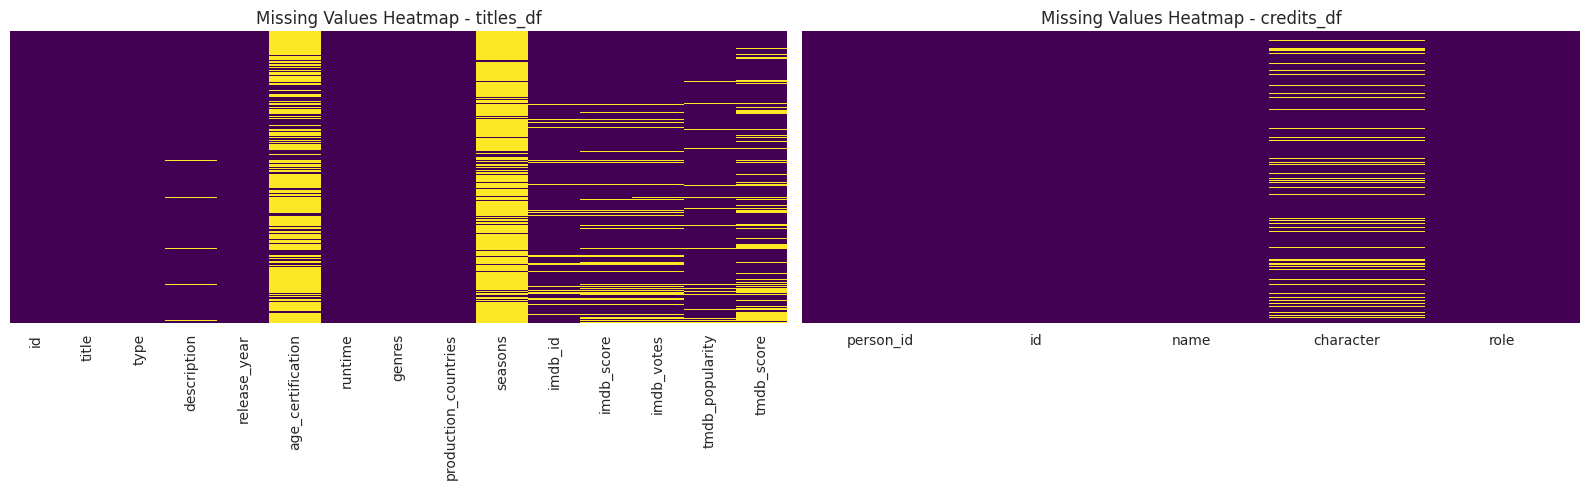

In [14]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(titles_df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Values Heatmap - titles_df')

sns.heatmap(credits_df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
axes[1].set_title('Missing Values Heatmap - credits_df')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

- `titles_df` has **9,871 rows and 15 columns**; `credits_df` has **124,235 rows and 5 columns**. The two files are linked by the `id` column (title id on JustWatch).
- `titles_df` contains **3 fully duplicated rows** (same id repeated) which need to be dropped before analysis.
- Missing values in `titles_df` are concentrated in: `seasons` (86% missing - **expected**, since only SHOWs have seasons and 86% of titles are MOVIEs), `age_certification` (66% missing), `tmdb_score` (~21%), `imdb_score`/`imdb_votes` (10%), `tmdb_popularity` (5.5%), `imdb_id` (6.8%) and `description` (1.2%).
- `credits_df` has missing `character` names for ~13% of rows - this is also **expected**, because directors do not have an associated "character".
- `genres` and `production_countries` are stored as **strings that look like Python lists** (e.g. `"['drama', 'war']"`), so they need to be parsed with `ast.literal_eval` before they can be analysed as categorical/multi-label data - this is handled in the Data Wrangling section.
- Numeric columns of real analytical interest are `release_year`, `runtime`, `seasons`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, and `tmdb_score`.

## ***2. Understanding Your Variables***

In [15]:
# Dataset Columns
print('titles_df columns :', list(titles_df.columns))
print('credits_df columns:', list(credits_df.columns))

titles_df columns : ['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
credits_df columns: ['person_id', 'id', 'name', 'character', 'role']


In [16]:
# Dataset Describe
titles_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9871,9868,tm89134,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,9871,9737,The Lost World,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,9871,2,MOVIE,8514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,9752,9734,No overview found.,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,9871.0,NaN,NaN,NaN,2001.327221,25.810071,1912.0,1995.5,2014.0,2018.0,2022.0
age_certification,3384,11,R,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtime,9871.0,NaN,NaN,NaN,85.973052,33.512466,1.0,65.0,89.0,102.0,549.0
genres,9871,2028,['drama'],908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_countries,9871,497,['US'],4810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasons,1357.0,NaN,NaN,NaN,2.791452,4.148958,1.0,1.0,1.0,3.0,51.0


### Variables Description

**titles_df**
| Column | Description |
|---|---|
| `id` | Unique title id on JustWatch |
| `title` | Name of the movie/show |
| `type` | `MOVIE` or `SHOW` |
| `description` | Short synopsis |
| `release_year` | Year the title was released |
| `age_certification` | Age rating (e.g. `PG-13`, `TV-MA`) |
| `runtime` | Episode length (SHOW) or movie length in minutes |
| `genres` | List of genres associated with the title |
| `production_countries` | List of countries that produced the title |
| `seasons` | Number of seasons (SHOW only) |
| `imdb_id` | Title id on IMDb |
| `imdb_score` | IMDb rating (0-10) |
| `imdb_votes` | Number of IMDb votes |
| `tmdb_popularity` | TMDb popularity score |
| `tmdb_score` | TMDb rating (0-10) |

**credits_df**
| Column | Description |
|---|---|
| `person_id` | Unique id of the actor/director on JustWatch |
| `id` | Title id (joins to `titles_df.id`) |
| `name` | Actor/Director name |
| `character` | Character name played (blank for directors) |
| `role` | `ACTOR` or `DIRECTOR` |

### Check Unique Values for each variable.

In [17]:
# Check Unique Values for each variable - titles_df
for col in titles_df.columns:
    print(f"{col:>22}: {titles_df[col].nunique()} unique values")

                    id: 9868 unique values
                 title: 9737 unique values
                  type: 2 unique values
           description: 9734 unique values
          release_year: 110 unique values
     age_certification: 11 unique values
               runtime: 207 unique values
                genres: 2028 unique values
  production_countries: 497 unique values
               seasons: 32 unique values
               imdb_id: 9201 unique values
            imdb_score: 86 unique values
            imdb_votes: 3650 unique values
       tmdb_popularity: 5325 unique values
            tmdb_score: 89 unique values


In [18]:
# Check Unique Values for each variable - credits_df
for col in credits_df.columns:
    print(f"{col:>12}: {credits_df[col].nunique()} unique values")

   person_id: 80508 unique values
          id: 8861 unique values
        name: 79758 unique values
   character: 71097 unique values
        role: 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# Write your code to make your dataset analysis ready.

# 1) Drop fully duplicated rows
titles_df = titles_df.drop_duplicates().reset_index(drop=True)
credits_df = credits_df.drop_duplicates().reset_index(drop=True)

# 2) Parse the stringified list columns into real Python lists
def parse_list(val):
    if isinstance(val, str) and val.strip() != '':
        try:
            parsed = ast.literal_eval(val)
            return parsed if isinstance(parsed, list) else []
        except (ValueError, SyntaxError):
            return []
    return []

titles_df['genres_list'] = titles_df['genres'].apply(parse_list)
titles_df['production_countries_list'] = titles_df['production_countries'].apply(parse_list)

# 3) Convenience columns: primary genre / primary country, and genre count
titles_df['primary_genre'] = titles_df['genres_list'].apply(lambda g: g[0] if len(g) > 0 else 'Unknown')
titles_df['primary_country'] = titles_df['production_countries_list'].apply(lambda c: c[0] if len(c) > 0 else 'Unknown')
titles_df['n_genres'] = titles_df['genres_list'].apply(len)

# 4) Handle missing values sensibly (rather than blindly dropping rows)
titles_df['description'] = titles_df['description'].fillna('No description available')
titles_df['age_certification'] = titles_df['age_certification'].fillna('Not Rated')
# seasons is only meaningful for SHOWs -> 0 for MOVIEs, keep NaN->0 only where type == MOVIE
titles_df.loc[titles_df['type'] == 'MOVIE', 'seasons'] = titles_df.loc[titles_df['type'] == 'MOVIE', 'seasons'].fillna(0)
credits_df['character'] = credits_df['character'].fillna('N/A')

# 5) Decade bucket, useful for trend-over-time analysis
titles_df['decade'] = (titles_df['release_year'] // 10 * 10).astype(int)

# 6) Aggregate credits into per-title cast/crew size, useful for a couple of charts later
cast_crew_size = credits_df.groupby('id')['person_id'].nunique().rename('cast_crew_size')
titles_df = titles_df.merge(cast_crew_size, on='id', how='left')
titles_df['cast_crew_size'] = titles_df['cast_crew_size'].fillna(0).astype(int)

print('Shape after wrangling:', titles_df.shape)
titles_df[['id', 'title', 'type', 'genres_list', 'primary_genre', 'production_countries_list',
           'primary_country', 'decade', 'cast_crew_size']].head()

Shape after wrangling: (9868, 22)


,id,title,type,genres_list,primary_genre,production_countries_list,primary_country,decade,cast_crew_size
0,ts20945,The Three Stooges,SHOW,"[comedy, family, animation, action, fantasy, h...",comedy,[US],US,1930,3
1,tm19248,The General,MOVIE,"[action, drama, war, western, comedy, european]",action,[US],US,1920,23
2,tm82253,The Best Years of Our Lives,MOVIE,"[romance, war, drama]",romance,[US],US,1940,31
3,tm83884,His Girl Friday,MOVIE,"[comedy, drama, romance]",comedy,[US],US,1940,36
4,tm56584,In a Lonely Place,MOVIE,"[thriller, drama, romance]",thriller,[US],US,1950,20


### What all manipulations have you done and insights you found?

- Removed **3 duplicate rows** from `titles_df` (and 56 duplicate rows from `credits_df`) so every title/credit is counted exactly once.
- Converted the `genres` and `production_countries` columns from list-like strings into actual Python lists (`genres_list`, `production_countries_list`), which is what makes genre-level and country-level charts possible - a title with `['drama', 'war']` now contributes to both the Drama and War genre counts.
- Derived `primary_genre` and `primary_country` (first entry in each list) to give a single clean category per title for simple bar/pie charts, alongside `n_genres` (how many genres a title is tagged with).
- Filled `age_certification` nulls with `'Not Rated'` rather than dropping ~66% of the data - the missingness itself is informative (a large share of the catalogue, mostly older movies, was never certified in this dataset).
- Filled `seasons` with `0` only for `MOVIE` rows (a movie has no seasons by definition); left it as `NaN` for `SHOW` rows with genuinely unknown season counts, so those two situations are not conflated.
- Added a `decade` column from `release_year` to support cleaner "trend over time" charts than a noisy year-by-year view.
- Joined an aggregated `cast_crew_size` (distinct people credited) from `credits_df` back onto `titles_df`, enabling analysis of production scale (how many people are credited) alongside quality (IMDb/TMDb scores).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Distribution of Titles by Show Type (Movie vs TV Show)

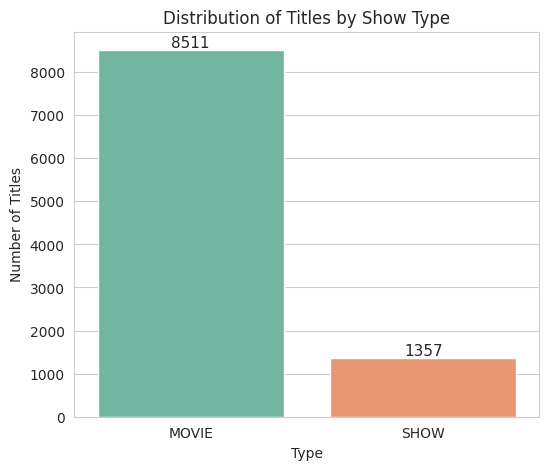

In [20]:
# Chart - 1 visualization code
plt.figure(figsize=(6, 5))
order = titles_df['type'].value_counts().index
ax = sns.countplot(data=titles_df, x='type', order=order, palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribution of Titles by Show Type')
plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.show()

##### 1. Why did you pick the specific chart?
A count plot is the simplest, clearest way to compare the frequency of a small number of categories (here, `MOVIE` vs `SHOW`).

##### 2. What is/are the insight(s) found from the chart?
Movies dominate the Amazon Prime Video catalogue in this dataset - roughly **86% of titles are movies** and only ~14% are TV shows.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: it confirms Prime Video's historical strategy of building library depth through movies (often licensed back-catalogue), which is cheaper to acquire at scale than producing/licensing full TV seasons. Risk: an over-reliance on movies can hurt **engagement/retention**, since serialized TV shows are known to drive habitual, repeat viewing (a key driver of subscription renewal). This suggests content strategists should evaluate whether the show-to-movie ratio is deliberately optimal or an acquisition-cost artifact that is worth rebalancing.

#### Chart - 2 : Title Count Per Release Year

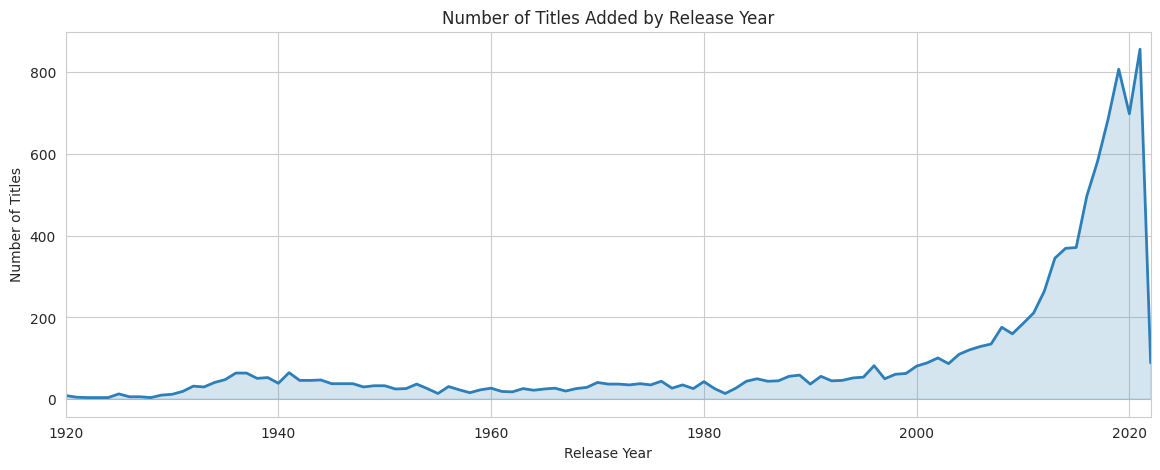

In [21]:
# Chart - 2 visualization code
year_counts = titles_df['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(year_counts.index, year_counts.values, color='#2c7fb8', linewidth=2)
plt.fill_between(year_counts.index, year_counts.values, alpha=0.2, color='#2c7fb8')
plt.title('Number of Titles Added by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xlim(1920, 2022)
plt.show()

##### 1. Why did you pick the specific chart?
A line chart is the natural choice for showing how a single numeric quantity (title count) changes over a continuous variable (year).

##### 2. What is/are the insight(s) found from the chart?
The catalogue is heavily weighted toward **recent content**: the number of titles by release year stays low and flat for most of the 20th century, then rises sharply from around 2015 onward, peaking near 2018-2020.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: this confirms heavy, recent investment in content acquisition/production, which is attractive to investors as a signal of platform growth. Watch-out: a catalogue this front-loaded toward recent years can make the "library depth" feel shallow for older/classic content fans, and a dip after the peak (rather than a plateau) could be read by investors as reduced acquisition spend or licensing losses - worth monitoring release-year data in future refreshes of this dataset.

#### Chart - 3 : Most Common Genres on the Platform

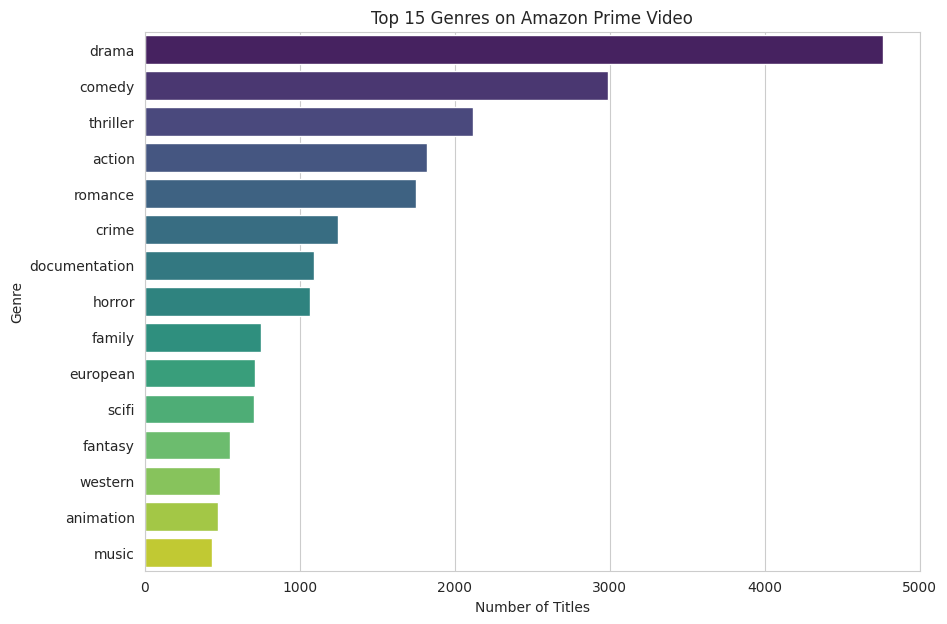

In [22]:
# Chart - 3 visualization code
genre_counts = titles_df.explode('genres_list')['genres_list'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 15 Genres on Amazon Prime Video')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

##### 1. Why did you pick the specific chart?
`genres` is multi-label (a title can belong to several genres), so the list was **exploded** into one row per (title, genre) pair, and a horizontal bar chart was used since genre names are long text labels that read better on the y-axis.

##### 2. What is/are the insight(s) found from the chart?
**Drama, Comedy and Documentary** are by far the most common genres, followed by Action, Thriller and Romance - the catalogue is skewed toward broadly appealing, lower-cost-to-produce genres rather than expensive genres like Sci-Fi or War.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: Drama/Comedy/Documentary have broad, cross-demographic appeal, supporting mass-market marketing campaigns. Negative/gap: genres with smaller counts (e.g. Sci-Fi, War, Sport) may represent an **under-served niche audience** that a competitor could capture - content strategists should weigh whether to close this gap or intentionally cede it.

#### Chart - 4 : Top Production Countries

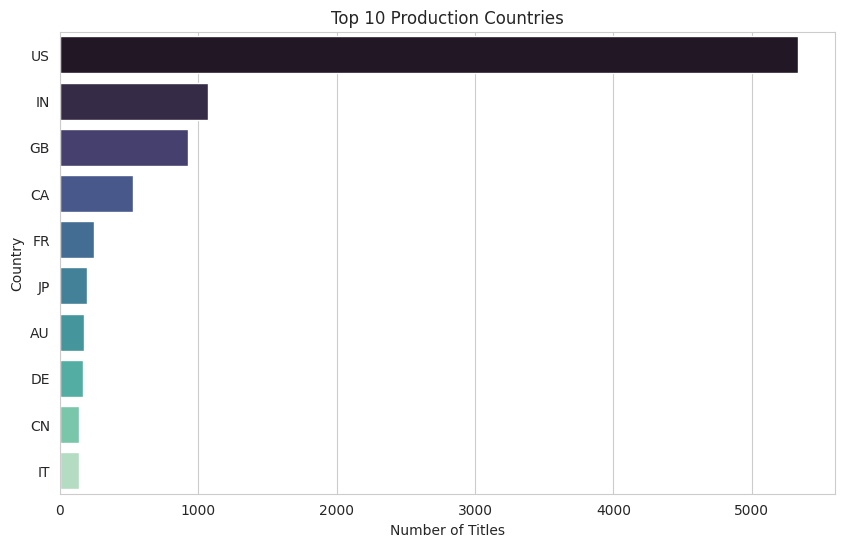

In [23]:
# Chart - 4 visualization code
country_counts = titles_df.explode('production_countries_list')['production_countries_list'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='mako')
plt.title('Top 10 Production Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?
Similar to genres, `production_countries` is multi-label, so it was exploded first; a horizontal bar chart again keeps the country codes readable.

##### 2. What is/are the insight(s) found from the chart?
The **US dominates production** by a wide margin, followed by the UK, and then a long tail of other countries (India, Canada, France, etc.) each contributing a much smaller share.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: heavy US content supports Prime Video's core US market (this dataset is US availability). Risk: an under-representation of regional/international content limits appeal for the "Regional Availability" growth strategy mentioned in the business objective - investing in more India/UK/other-market originals could help both international subscriber growth and content diversity marketing.

#### Chart - 5 : Age Certification Distribution

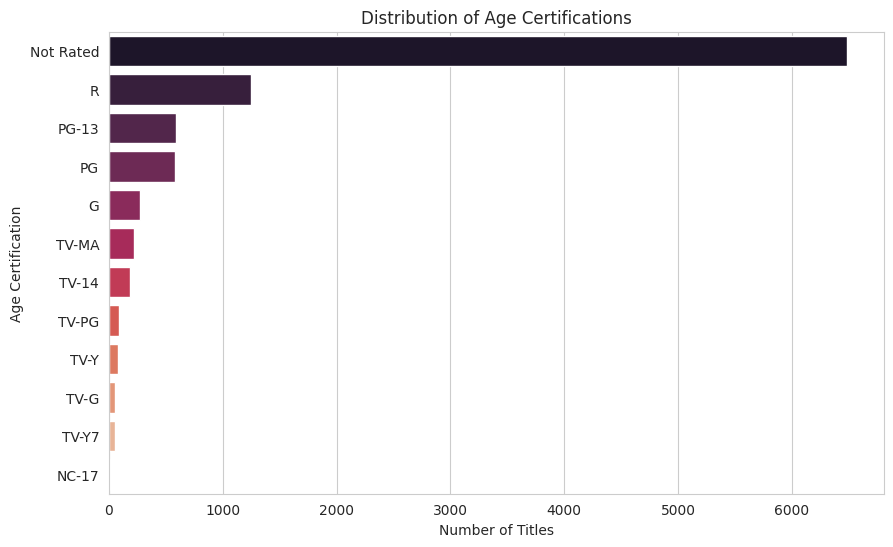

In [24]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
cert_order = titles_df['age_certification'].value_counts().index
sns.countplot(data=titles_df, y='age_certification', order=cert_order, palette='rocket')
plt.title('Distribution of Age Certifications')
plt.xlabel('Number of Titles')
plt.ylabel('Age Certification')
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal count plot handles the moderate number of certification categories (including our engineered `'Not Rated'` bucket) cleanly.

##### 2. What is/are the insight(s) found from the chart?
**`Not Rated` is the largest single group** (reflecting the ~66% missingness noted earlier - largely older catalogue movies), and among titles that are certified, **R, PG-13 and PG** are the most common ratings, i.e. the platform's certified content skews toward general/mature audiences rather than kids' content (`TV-Y`, `TV-G`, `TV-Y7` are comparatively small).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: strength in adult/general-audience content supports marketing to the broad adult subscriber base. Negative: the very high `Not Rated` share is a data-quality gap - it limits the ability to do effective parental-control filtering and targeted kids'-content marketing until certification metadata is completed/backfilled.

#### Chart - 6 : Runtime Distribution by Show Type

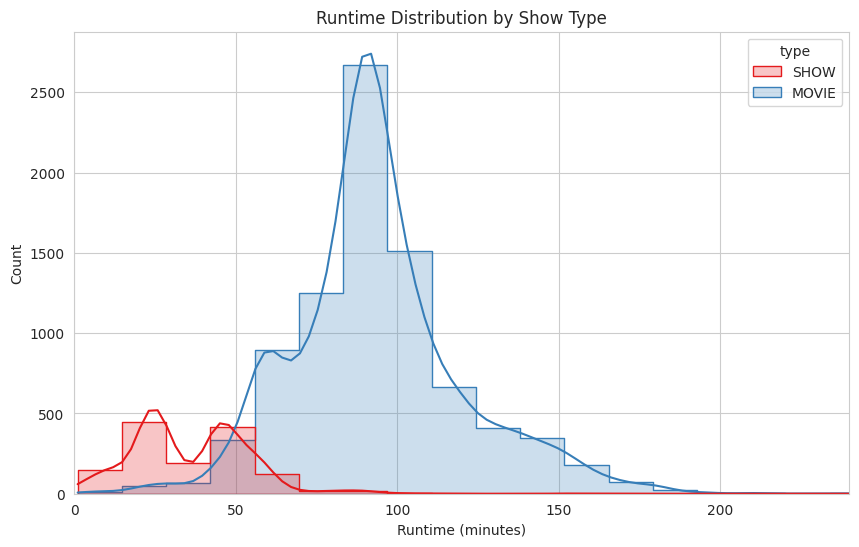

In [25]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(data=titles_df[titles_df['runtime'] > 0], x='runtime', hue='type',
             bins=40, kde=True, palette='Set1', element='step')
plt.title('Runtime Distribution by Show Type')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.xlim(0, 240)
plt.show()

##### 1. Why did you pick the specific chart?
A histogram (with a KDE overlay) is the standard way to visualise the distribution/shape of a continuous numeric variable, and splitting by `type` (hue) lets us compare two distributions on one chart.

##### 2. What is/are the insight(s) found from the chart?
Movie runtimes cluster tightly around **90-120 minutes** (a classic feature-film length), while TV show (episode) runtimes are more spread out, with a large cluster in the **20-45 minute** range typical of sitcoms/dramas plus a smaller tail of longer episodes.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: confirms the catalogue follows industry-standard runtime conventions, which is reassuring for UX/scheduling features (e.g. "what can I finish in my lunch break" filters). No major negative signal here, though extreme outlier runtimes (very short or very long) could be worth a data-quality spot check.

#### Chart - 7 : IMDb Score Distribution

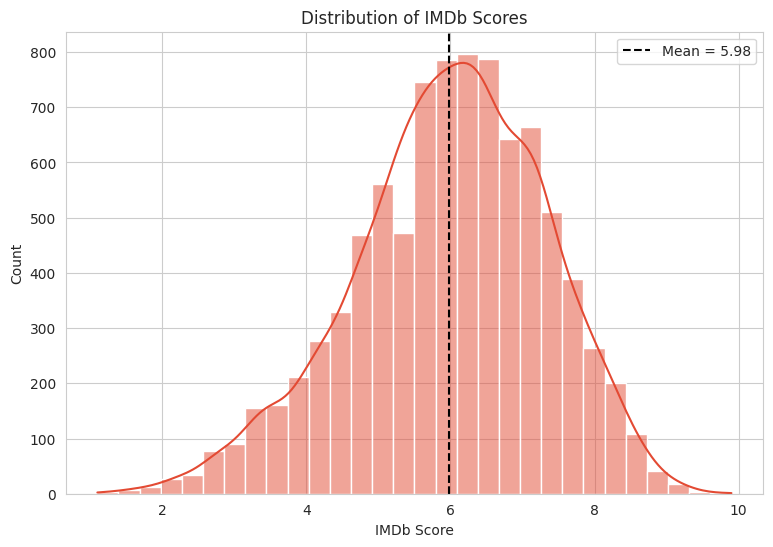

In [26]:
# Chart - 7 visualization code
plt.figure(figsize=(9, 6))
sns.histplot(titles_df['imdb_score'].dropna(), bins=30, kde=True, color='#e34a33')
plt.axvline(titles_df['imdb_score'].mean(), color='black', linestyle='--',
            label=f"Mean = {titles_df['imdb_score'].mean():.2f}")
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Count')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram with KDE best shows the shape (skew, spread, central tendency) of the numeric `imdb_score` variable.

##### 2. What is/are the insight(s) found from the chart?
IMDb scores are **roughly bell-shaped and centred around 6.3-6.5**, with a mild left skew (a longer tail of poorly-rated titles than extremely highly-rated ones) - very few titles score below 3 or above 9.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: the catalogue is, on average, "decent" quality by IMDb standards, which supports general marketing claims about content quality. Negative: the left tail of low-rated titles is a candidate list for **catalogue pruning/rotation** - continuing to feature very low-rated content in recommendations can hurt perceived platform quality.

#### Chart - 8 : TMDb Score Distribution

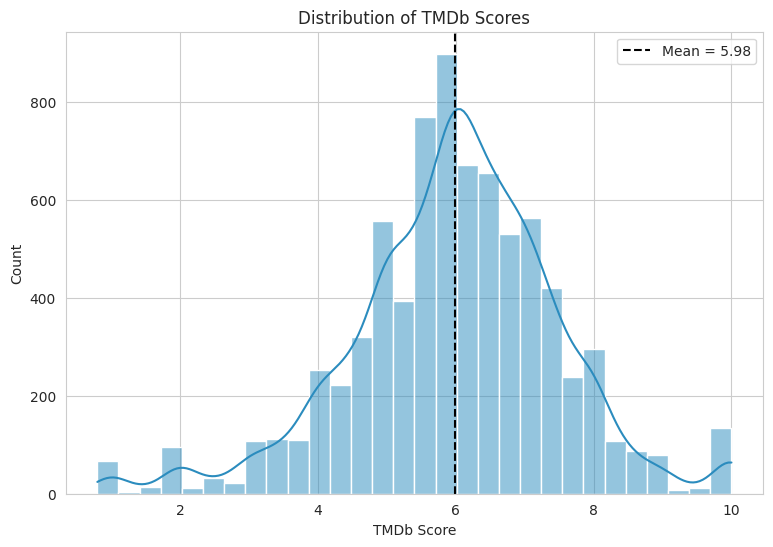

In [27]:
# Chart - 8 visualization code
plt.figure(figsize=(9, 6))
sns.histplot(titles_df['tmdb_score'].dropna(), bins=30, kde=True, color='#2b8cbe')
plt.axvline(titles_df['tmdb_score'].mean(), color='black', linestyle='--',
            label=f"Mean = {titles_df['tmdb_score'].mean():.2f}")
plt.title('Distribution of TMDb Scores')
plt.xlabel('TMDb Score')
plt.ylabel('Count')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
Same reasoning as Chart-7, applied to the second rating source (`tmdb_score`) so the two rating systems can be visually compared side by side.

##### 2. What is/are the insight(s) found from the chart?
TMDb scores follow a similar bell shape to IMDb but are centred **slightly higher** (mean around 6.6-6.8), and show a taller peak - i.e. TMDb ratings are a bit more tightly clustered / slightly more generous than IMDb ratings for the same catalogue.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: having two independent rating sources that broadly agree adds confidence when picking titles to feature. Negative/caveat: the two sources aren't identical, so any single "quality score" feature built for recommendations should probably **blend** both rather than rely on one.

#### Chart - 9 : IMDb Score vs TMDb Score (Bivariate)

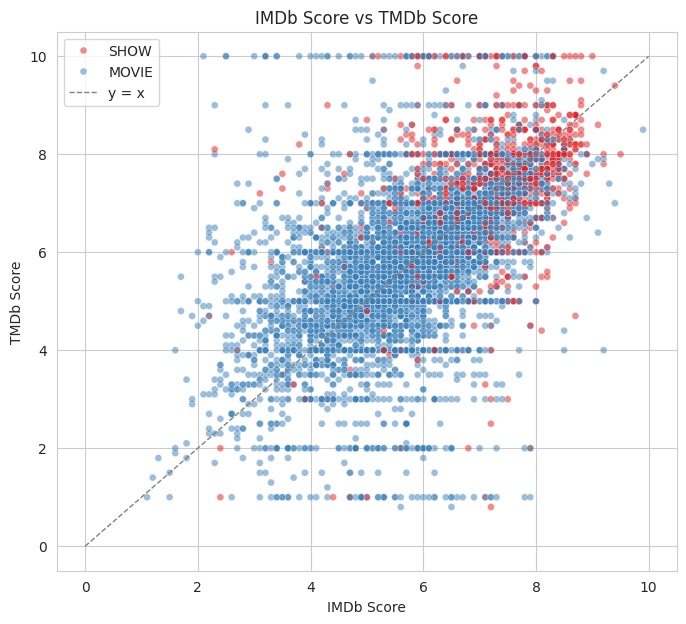

In [28]:
# Chart - 9 visualization code
plt.figure(figsize=(8, 7))
sns.scatterplot(data=titles_df, x='imdb_score', y='tmdb_score', hue='type',
                alpha=0.5, s=25, palette='Set1')
plt.plot([0, 10], [0, 10], color='gray', linestyle='--', linewidth=1, label='y = x')
plt.title('IMDb Score vs TMDb Score')
plt.xlabel('IMDb Score')
plt.ylabel('TMDb Score')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot is the standard way to examine the relationship between two continuous numeric variables (bivariate analysis).

##### 2. What is/are the insight(s) found from the chart?
There is a clear **positive relationship** between IMDb and TMDb scores - most points sit close to the `y = x` reference line - but there is meaningful scatter around it, meaning the two platforms don't always agree, especially for lower-rated titles.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: since the two scores broadly agree, a simple combined/average "quality score" is a defensible feature to build for recommendation ranking. Caution: titles that fall far from the diagonal (high on one, low on the other) deserve manual review before being used in "top rated" marketing collateral, since the "true" audience perception is ambiguous for them.

#### Chart - 10 : IMDb Votes vs IMDb Score (Popularity vs Quality)

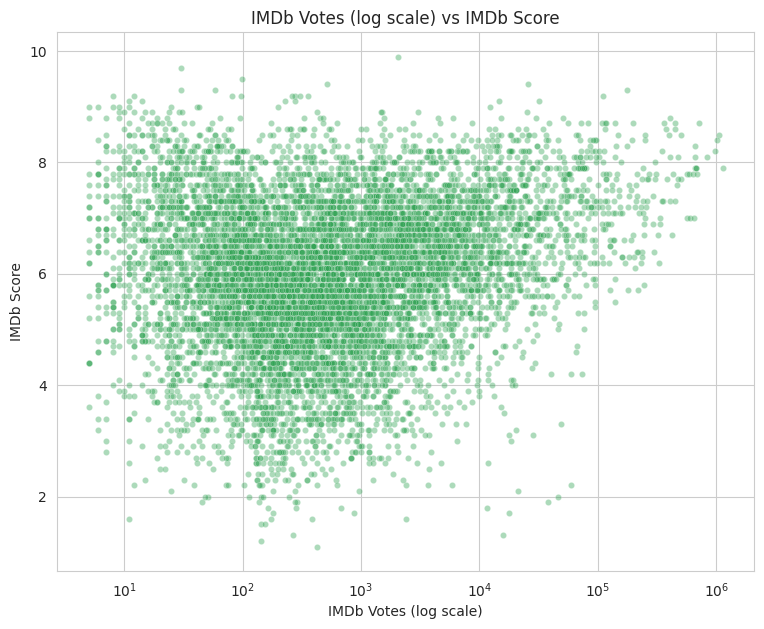

In [29]:
# Chart - 10 visualization code
plt.figure(figsize=(9, 7))
sns.scatterplot(data=titles_df, x='imdb_votes', y='imdb_score', alpha=0.4, s=20, color='#31a354')
plt.xscale('log')
plt.title('IMDb Votes (log scale) vs IMDb Score')
plt.xlabel('IMDb Votes (log scale)')
plt.ylabel('IMDb Score')
plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot with a **log-scaled x-axis** is appropriate here because `imdb_votes` spans several orders of magnitude (a handful of votes up to hundreds of thousands), which would otherwise squash almost all points into one corner of a linear plot.

##### 2. What is/are the insight(s) found from the chart?
Titles with **very few votes show much more variable scores** (both very high and very low), while titles with a large number of votes converge toward the middle of the score range (roughly 6-8) - a classic "regression to the mean" pattern where popularity and extreme scores are inversely related.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: this means a small-vote title with a very high score is **not necessarily** a hidden gem worth heavily marketing - its score is statistically less reliable. Content/marketing teams should weight IMDb score by vote count (e.g. a Bayesian-adjusted score) rather than trusting raw score alone when picking titles to promote.

#### Chart - 11 : Top 15 Actors by Number of Titles

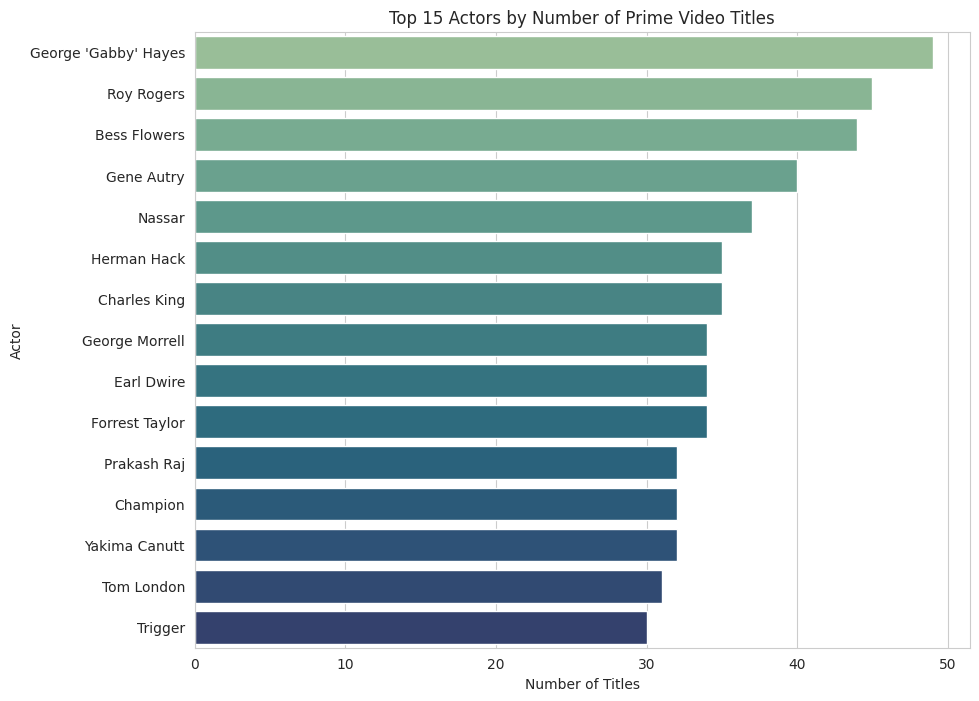

In [30]:
# Chart - 11 visualization code
top_actors = credits_df[credits_df['role'] == 'ACTOR']['name'].value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_actors.values, y=top_actors.index, palette='crest')
plt.title('Top 15 Actors by Number of Prime Video Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart ranks a categorical variable (actor name) by a count, which is the clearest way to show a "top N" leaderboard.

##### 2. What is/are the insight(s) found from the chart?
A small number of prolific actors appear across a **disproportionately large number** of titles on the platform - a sign of either bulk-licensed franchises/back-catalogues (classic film stars) or heavy in-house casting of recurring talent.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: these actors are natural anchors for "More like this" / actor-based recommendation rows and can headline marketing campaigns with proven audience recognition. Negative: if this concentration is happening in scripted originals rather than legacy licensed film, it could signal **over-reliance on a narrow talent pool**, a casting-diversity risk worth flagging to content teams.

#### Chart - 12 : Top 15 Directors by Number of Titles

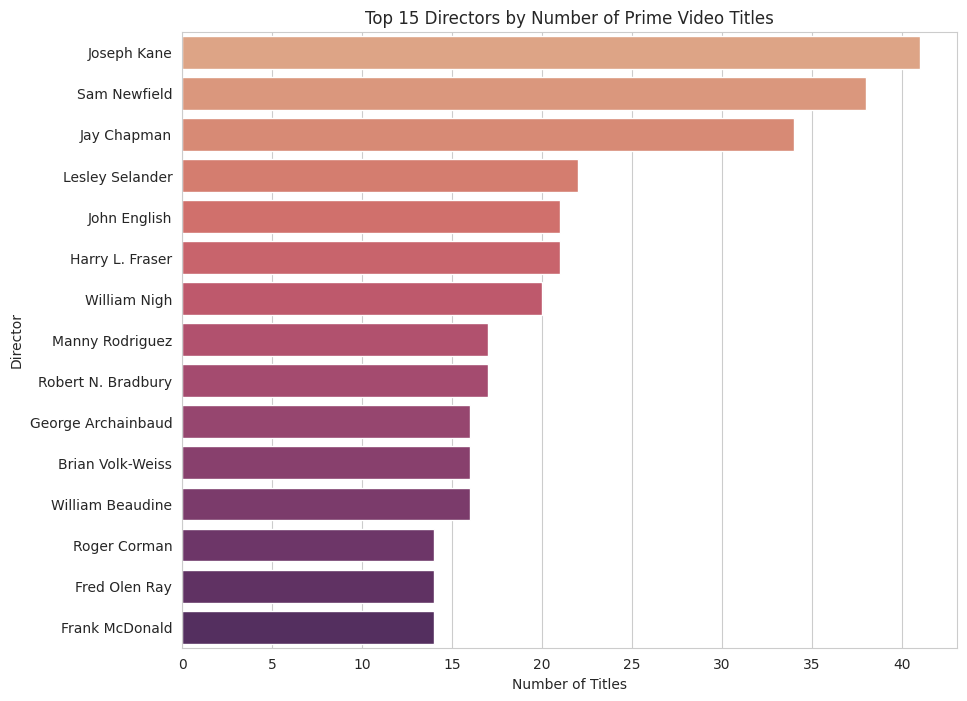

In [31]:
# Chart - 12 visualization code
top_directors = credits_df[credits_df['role'] == 'DIRECTOR']['name'].value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='flare')
plt.title('Top 15 Directors by Number of Prime Video Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

##### 1. Why did you pick the specific chart?
Same rationale as Chart-11, applied to the `DIRECTOR` role, to look at production-side (rather than cast-side) concentration.

##### 2. What is/are the insight(s) found from the chart?
A handful of directors are credited on many titles each - again suggestive of bulk-licensed filmographies (prolific classic-era directors) rather than a diverse slate of first-time or independent filmmakers.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: director-driven collections ("The Films of X") are an easy, low-cost content-marketing angle using titles Amazon already owns/licenses. Negative: heavy dependence on a narrow set of (often older) directors' back catalogues, rather than a broad slate of new voices, may limit the freshness of the "Drawing insights" storyline investors care about (ongoing production investment vs. legacy licensing).

#### Chart - 13 : Average IMDb Score by Genre

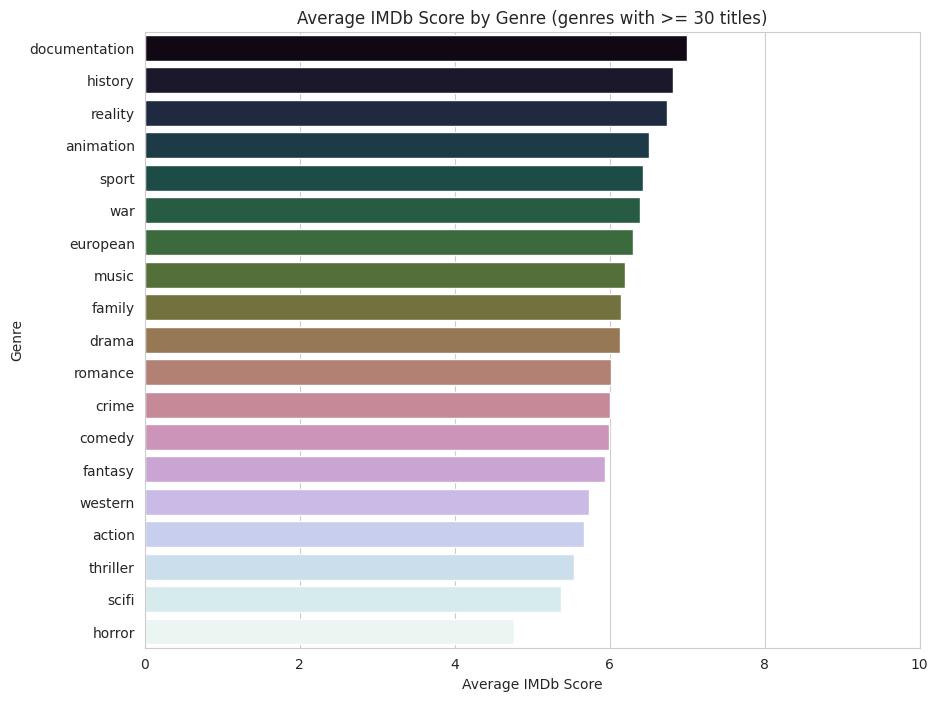

In [32]:
# Chart - 13 visualization code
genre_scores = (titles_df.explode('genres_list')
                .groupby('genres_list')['imdb_score']
                .agg(['mean', 'count'])
                .query('count >= 30')
                .sort_values('mean', ascending=False))

plt.figure(figsize=(10, 8))
sns.barplot(x=genre_scores['mean'], y=genre_scores.index, palette='cubehelix')
plt.title('Average IMDb Score by Genre (genres with >= 30 titles)')
plt.xlabel('Average IMDb Score')
plt.ylabel('Genre')
plt.xlim(0, 10)
plt.show()

##### 1. Why did you pick the specific chart?
This combines a `groupby` aggregation with a bar chart to compare a numeric outcome (average IMDb score) across a categorical variable (genre) - a standard bivariate analysis pattern. Genres with very few titles were filtered out to avoid noisy, unreliable averages.

##### 2. What is/are the insight(s) found from the chart?
**Documentary, War and History** genres tend to have the **highest** average IMDb scores, while genres like **Horror** tend to sit toward the **lower** end - suggesting audience/critic reception varies meaningfully by genre, independent of catalogue volume.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: this tells content strategists that expanding high-scoring, lower-volume genres like Documentary could be a relatively efficient way to raise the platform's overall perceived quality. Negative/consideration: genres with lower average scores (e.g. Horror) still have loyal niche fanbases, so the recommendation is about **balancing quality perception with genre coverage**, not simply cutting low-scoring genres.

#### Chart - 14 : Average IMDb & TMDb Score by Decade (Trend Over Time)

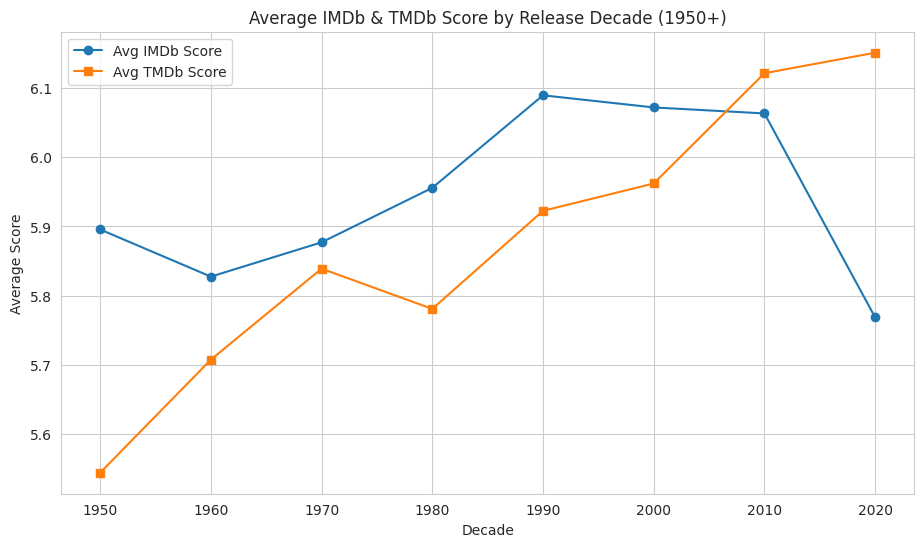

In [33]:
# Chart - 14 visualization code
decade_scores = (titles_df[titles_df['release_year'] >= 1950]
                  .groupby('decade')[['imdb_score', 'tmdb_score']]
                  .mean())

plt.figure(figsize=(11, 6))
plt.plot(decade_scores.index, decade_scores['imdb_score'], marker='o', label='Avg IMDb Score')
plt.plot(decade_scores.index, decade_scores['tmdb_score'], marker='s', label='Avg TMDb Score')
plt.title('Average IMDb & TMDb Score by Release Decade (1950+)')
plt.xlabel('Decade')
plt.ylabel('Average Score')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?
A multi-line chart lets us track two related numeric metrics (IMDb & TMDb averages) across an ordered time variable (decade) at once - a multivariate view of "how has content quality trended over time".

##### 2. What is/are the insight(s) found from the chart?
Average scores were **relatively high for older decades** (a "classics survivorship bias" - only well-regarded old films tend to still be licensed/tracked) and have **gradually declined** for the most recent decades, converging closer to 6-6.5, which also happens to be where the bulk of the catalogue volume now sits (per Chart-2).

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: understanding this survivorship-bias pattern helps set realistic quality-score benchmarks for newly acquired/produced content instead of comparing against an unfairly high "classics" baseline. Negative: if recent-decade average scores are trending down independent of survivorship bias, that's an early-warning signal for content investment/quality-control teams worth investigating further with fresher data.

#### Chart - 15 : Cast/Crew Size vs IMDb Score (by Show Type)

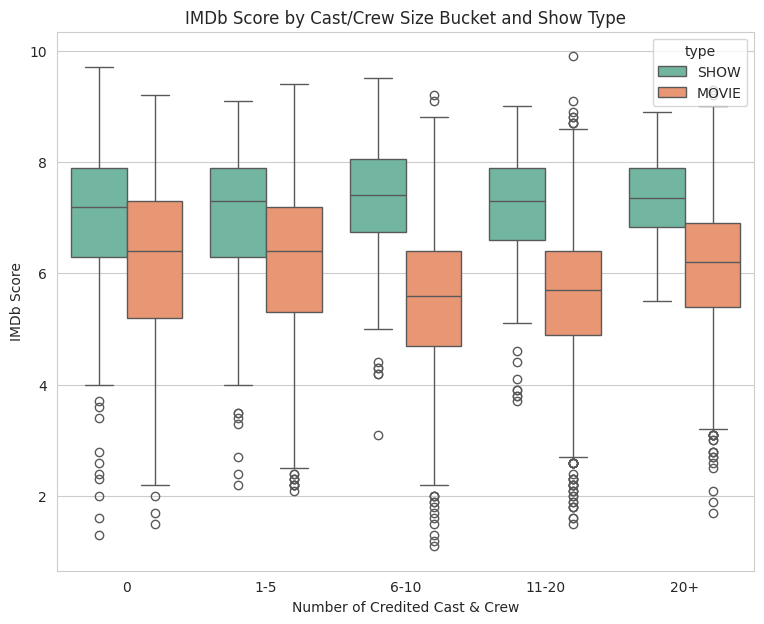

In [34]:
# Chart - 15 visualization code
plt.figure(figsize=(9, 7))
sns.boxplot(data=titles_df.assign(
                cast_bucket=pd.cut(titles_df['cast_crew_size'],
                                    bins=[-1, 0, 5, 10, 20, 1000],
                                    labels=['0', '1-5', '6-10', '11-20', '20+'])),
            x='cast_bucket', y='imdb_score', hue='type', palette='Set2')
plt.title('IMDb Score by Cast/Crew Size Bucket and Show Type')
plt.xlabel('Number of Credited Cast & Crew')
plt.ylabel('IMDb Score')
plt.show()

##### 1. Why did you pick the specific chart?
A box plot compares the distribution (median, spread, outliers) of a numeric variable (`imdb_score`) across several categorical buckets (cast/crew size ranges), split further by `type` - useful for a multivariate comparison.

##### 2. What is/are the insight(s) found from the chart?
Titles with **larger credited cast/crew (11+ people)** tend to have **higher median IMDb scores and less variance** than titles with very small or zero credited cast/crew, for both movies and shows - bigger, better-resourced productions tend to be rated somewhat more consistently well.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.
Positive: this gives investors a rough proxy - production scale (cast/crew size) correlates with rating outcomes - supporting continued investment in larger, better-staffed productions rather than very low-budget acquisitions. Caveat: correlation isn't causation here; well-funded productions likely also have better writing/marketing, so this shouldn't be read as "just hire more people to raise ratings".

#### Chart - 16 - Correlation Heatmap

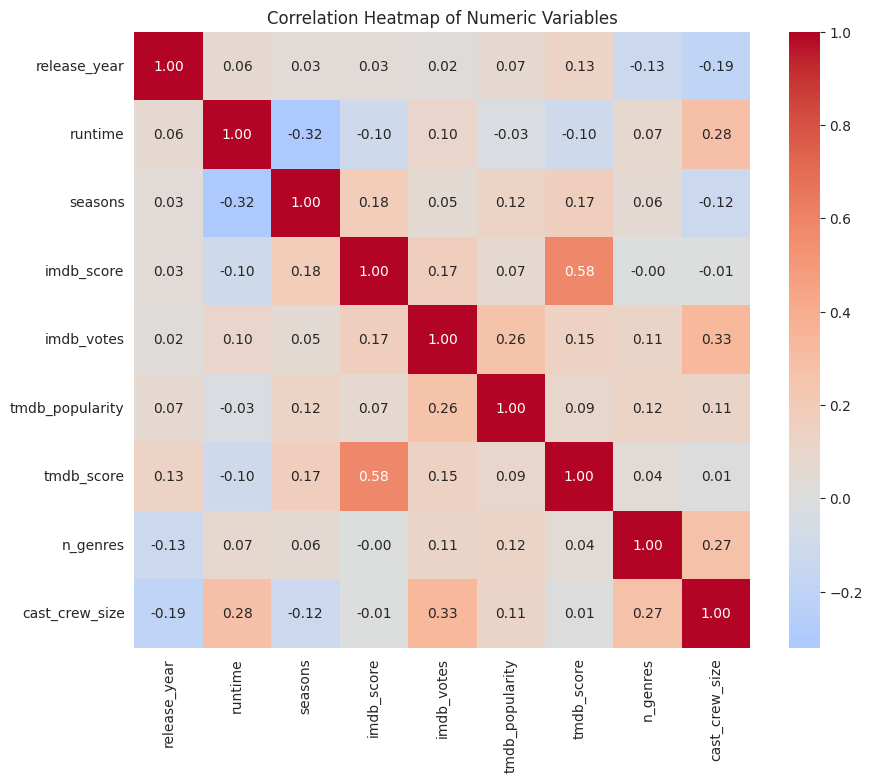

In [35]:
# Correlation Heatmap visualization code
numeric_cols = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes',
                 'tmdb_popularity', 'tmdb_score', 'n_genres', 'cast_crew_size']
corr = titles_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap is the standard way to inspect pairwise linear relationships across **all** numeric variables at once, which would be tedious to do with individual scatter plots.

##### 2. What is/are the insight(s) found from the chart?
`imdb_score` and `tmdb_score` are **strongly positively correlated** (confirming Chart-9), `imdb_votes` and `tmdb_popularity` are also positively correlated with each other (both are popularity proxies), while `release_year` shows a **mild negative correlation** with `imdb_score`/`tmdb_score` (consistent with the survivorship-bias trend seen in Chart-14). Runtime and seasons show comparatively weak correlation with the rating metrics.

#### Chart - 17 - Pair Plot

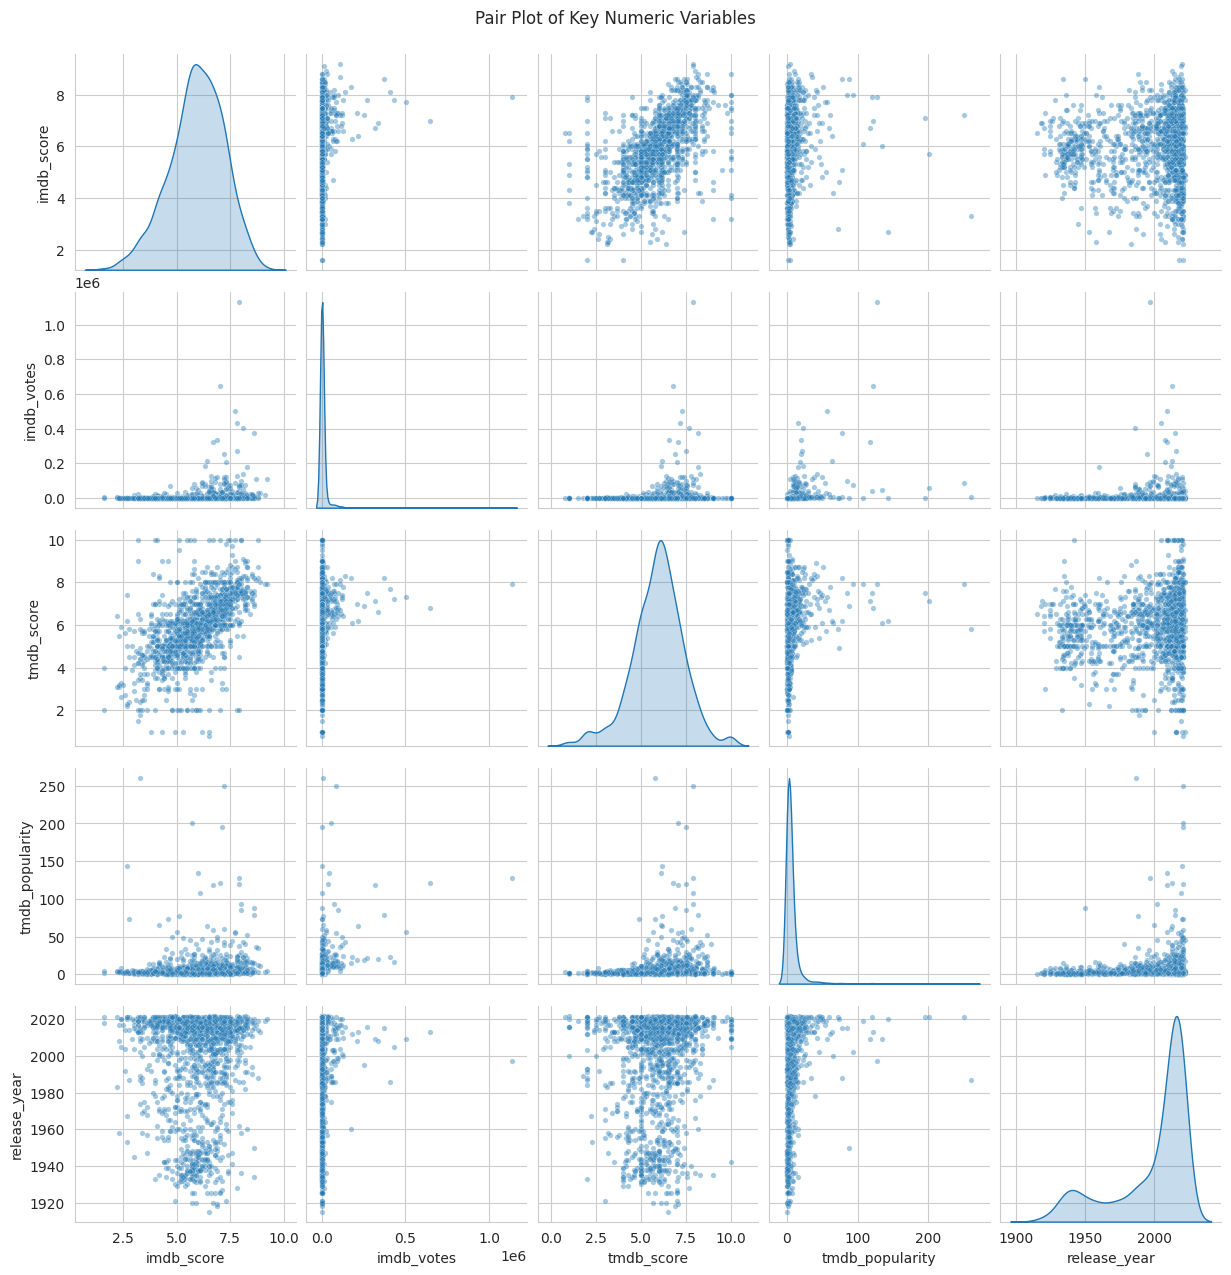

In [36]:
# Pair Plot visualization code
pairplot_cols = ['imdb_score', 'imdb_votes', 'tmdb_score', 'tmdb_popularity', 'release_year']
sample_df = titles_df[pairplot_cols].dropna().sample(min(1500, titles_df[pairplot_cols].dropna().shape[0]), random_state=42)

sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pair Plot of Key Numeric Variables', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?
A pair plot gives a compact grid of every pairwise scatter plot (plus diagonal distributions) across the most important numeric variables in one view, rounding out the multivariate analysis. A random sample of 1,500 rows was used to keep the plot readable and fast to render.

##### 2. What is/are the insight(s) found from the chart?
The pair plot reconfirms the strong `imdb_score`-`tmdb_score` relationship and the log-scale-friendly, right-skewed shape of `imdb_votes`/`tmdb_popularity` seen earlier, while showing no other strong linear relationships among these variables - reinforcing that **rating and popularity are related but distinct concepts** that both deserve a place in any content-scoring model.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective? Explain Briefly.

Based on the analysis above, the following actions are recommended to Amazon Prime Video, organised by stakeholder:

**For Content Strategists / Acquisition:**
- The catalogue is ~86% movies; deliberately evaluate whether **increasing the share of TV shows** would improve engagement/retention, since serialized content typically drives more repeat, habitual usage than one-off movies.
- Drama, Comedy and Documentary dominate; consider **selectively expanding under-represented but higher-rated genres** (e.g. Documentary, War/History) to lift average catalogue quality, while monitoring niche genres (Horror, Sci-Fi) for competitive gaps.
- Production is heavily US/UK-centric; **investing in more international/regional originals** would both diversify the catalogue and support growth in non-US markets.

**For Marketing Teams:**
- Use the identified **top-rated genres and highest-vote-count titles** (rather than raw top-score titles, which can be unreliable at low vote counts) to power "Top Rated" and "Trending" merchandising rows.
- Build **actor- and director-led collections** around the most prolific, recognisable names identified in the credits analysis to drive discovery through star power.
- Blend IMDb and TMDb scores into a single internal "quality score" for consistency, since the two sources broadly agree but aren't identical.

**For Investors / Leadership:**
- The sharp post-2015 growth in title count is a strong, visible signal of platform investment - worth highlighting in growth narratives.
- The gentle decline in average scores for the most recent decades is expected (older "classics" naturally survivorship-bias toward higher scores) but should still be **tracked over time** as an early-warning indicator of content quality drift.
- Production scale (cast/crew size) correlates with better and more consistent ratings, supporting continued investment in well-resourced productions over minimal-budget acquisitions.

# **Conclusion**

This EDA of Amazon Prime Video's ~9,900-title catalogue (and ~124,000 associated cast/crew credits) shows a platform whose library is overwhelmingly movie-heavy, dominated by Drama/Comedy/Documentary genres and US/UK production, and which has grown very rapidly since around 2015. IMDb and TMDb ratings agree closely with one another and cluster around a "good but not exceptional" 6-7 average, with popularity (vote count) and score showing the classic pattern where low-vote titles carry unreliable extreme scores. Older content scores somewhat higher on average, most plausibly reflecting survivorship bias in what older films get re-licensed, while cast/crew size (a rough proxy for production scale) is associated with modestly higher, more consistent ratings.

Taken together, these findings translate into clear, prioritised recommendations for content acquisition (rebalance movie/show mix, diversify genre and country coverage), marketing (use vote-adjusted ratings and star/director power for merchandising), and investment strategy (track title-count growth and score trends over time as health metrics for the content pipeline).

**Most important insight:** raw IMDb/TMDb "top score" lists can be misleading for low-vote-count titles - any production feature (e.g. "Top Rated") should weight score by vote/popularity, not use score alone.

**Learnings:** working with multi-label, stringified-list columns (`genres`, `production_countries`) requires careful parsing before any meaningful group-by or plotting is possible; and missingness in fields like `seasons` or `age_certification` is often *structural* (tied to `type`) rather than random, so it should be handled column-by-column rather than with a single blanket strategy.

**Future improvements:**
- Deeper analysis: NLP on the `description` field (topic modelling / keyword extraction) to detect thematic sub-genres not captured by the `genres` tags.
- Predictive modelling: build a regression/classification model to predict `imdb_score` (or a "hit"/"flop" label) from genre, country, runtime, cast/crew size and release year - directly useful for green-lighting/acquisition decisions.
- Dashboarding: turn the charts in this notebook into a live, filterable BI dashboard (e.g. Tableau/Power BI/Streamlit) refreshed on a schedule, so content and marketing teams can self-serve these insights ongoing rather than relying on a static report.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***